# 08 — SHAP Analysis

Purpose: generate SHAP explainability outputs for the tuned XGBoost churn model.

This notebook is designed to run locally after the modeling notebooks have produced `outputs/models/xgboost.pkl`, `data/processed/test.parquet`, and the project `src/` modules.

In [1]:
# Imports
from pathlib import Path
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    raise ImportError("Install SHAP first: pip install shap")

# Make project root importable when running from notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.config import TEST_PATH, MODELS, FIGURES, TABLES, RANDOM_SEED

In [2]:
# Paths
SHAP_FIGURES = FIGURES / "08_shap"
SHAP_FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS / "xgboost.pkl"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model path: {MODEL_PATH}")
print(f"SHAP figures: {SHAP_FIGURES}")

Project root: c:\Users\User\Desktop\315 - retain IQ\retainiq
Model path: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\models\xgboost.pkl
SHAP figures: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap


In [3]:
# Load test data and model
df_test = pd.read_parquet(TEST_PATH)
xgb_pipe = joblib.load(MODEL_PATH)

TARGET = "churned"
METADATA = ["wallet_id", "full_name", "churned_vendor"]

MODEL_COLS = [c for c in df_test.columns if c not in [TARGET] + METADATA]
y_test = df_test[TARGET].values

print("Test shape:", df_test.shape)
print("Model columns:", len(MODEL_COLS))
print("Pipeline steps:", xgb_pipe.named_steps.keys())

Test shape: (75108, 38)
Model columns: 34
Pipeline steps: dict_keys(['preprocessor', 'classifier'])


In [4]:
# Resolve pipeline step names robustly
if "preprocessor" in xgb_pipe.named_steps:
    preprocessor = xgb_pipe.named_steps["preprocessor"]
elif "pre" in xgb_pipe.named_steps:
    preprocessor = xgb_pipe.named_steps["pre"]
else:
    raise KeyError(f"Could not find preprocessor step. Found: {xgb_pipe.named_steps.keys()}")

if "classifier" in xgb_pipe.named_steps:
    xgb_clf = xgb_pipe.named_steps["classifier"]
elif "clf" in xgb_pipe.named_steps:
    xgb_clf = xgb_pipe.named_steps["clf"]
else:
    raise KeyError(f"Could not find classifier step. Found: {xgb_pipe.named_steps.keys()}")

print("Preprocessor:", type(preprocessor))
print("Classifier:", type(xgb_clf))

Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Classifier: <class 'xgboost.sklearn.XGBClassifier'>


In [5]:
# Transform test data using the fitted preprocessor
X_test_transformed = preprocessor.transform(df_test[MODEL_COLS])

# Convert sparse matrix if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed_dense = X_test_transformed.toarray()
else:
    X_test_transformed_dense = np.asarray(X_test_transformed)

# Feature names from preprocessor
try:
    feature_names = preprocessor.get_feature_names_out()
    feature_names = [
        name.replace("num__", "").replace("cat__", "").replace("remainder__", "")
        for name in feature_names
    ]
except Exception:
    feature_names = [f"feature_{i}" for i in range(X_test_transformed_dense.shape[1])]

print("Transformed shape:", X_test_transformed_dense.shape)
print("Feature names:", len(feature_names))

Transformed shape: (75108, 34)
Feature names: 34


In [6]:
# SHAP subsample for speed
np.random.seed(RANDOM_SEED)

sample_size = min(2000, X_test_transformed_dense.shape[0])
idx = np.random.choice(X_test_transformed_dense.shape[0], size=sample_size, replace=False)

X_shap = X_test_transformed_dense[idx]
y_shap = y_test[idx]

print(f"SHAP sample size: {sample_size}")

SHAP sample size: 2000


In [7]:
# Compute SHAP values
explainer = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_shap)

# Compatibility: some versions return a list for binary classifiers
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (2000, 34)


C:\Users\User\AppData\Local\Temp\ipykernel_5180\2322776413.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


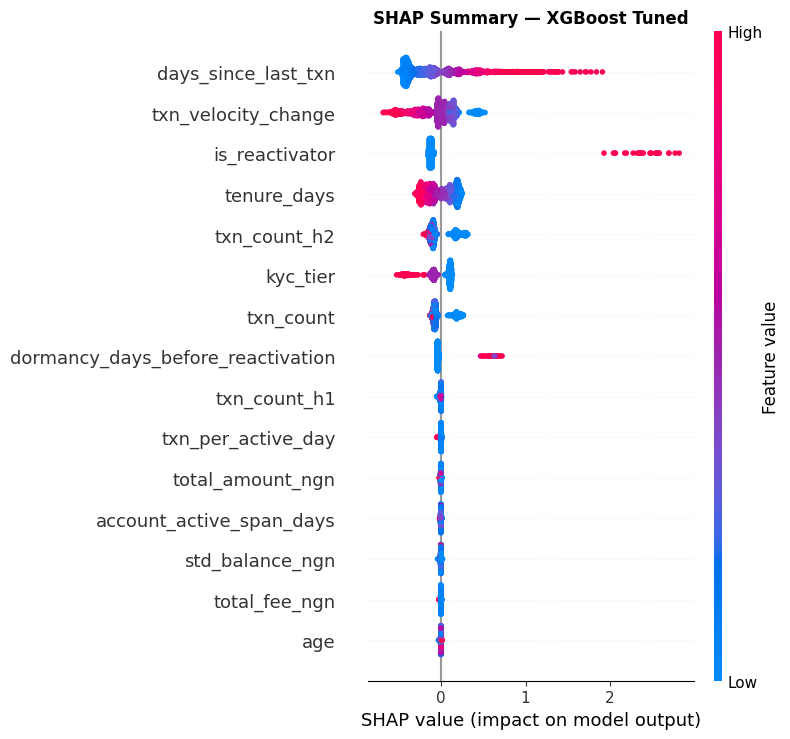

Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap\shap_summary.png


In [8]:
# Global SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Summary — XGBoost Tuned", fontweight="bold")
plt.tight_layout()
plt.savefig(SHAP_FIGURES / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {SHAP_FIGURES / 'shap_summary.png'}")

In [9]:
# Mean absolute SHAP importance table
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

shap_importance.to_csv(TABLES / "shap_importance.csv", index=False)

display(shap_importance.head(20))
print(f"Saved: {TABLES / 'shap_importance.csv'}")

,feature,mean_abs_shap
0,days_since_last_txn,0.333456
1,txn_velocity_change,0.176550
2,is_reactivator,0.155942
3,tenure_days,0.148292
4,txn_count_h2,0.132286
5,kyc_tier,0.131603
6,txn_count,0.102380
7,dormancy_days_before_reactivation,0.044508
8,txn_count_h1,0.005909
9,txn_per_active_day,0.003592


Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\tables\shap_importance.csv


C:\Users\User\AppData\Local\Temp\ipykernel_5180\623702463.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


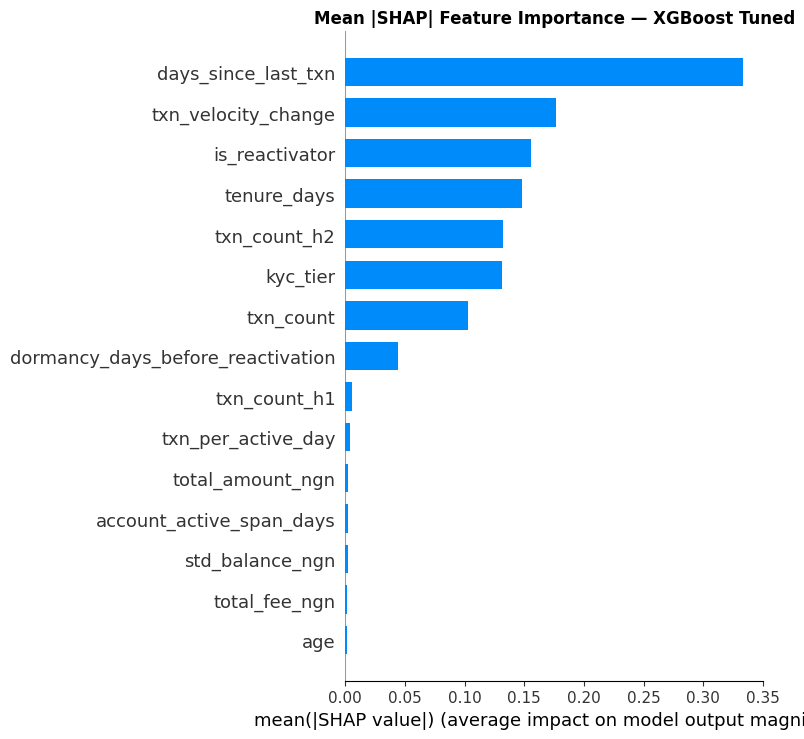

Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap\shap_bar.png


In [10]:
# SHAP bar plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean |SHAP| Feature Importance — XGBoost Tuned", fontweight="bold")
plt.tight_layout()
plt.savefig(SHAP_FIGURES / "shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {SHAP_FIGURES / 'shap_bar.png'}")

In [11]:
# Pick three explainable examples: high, medium, and low predicted risk
test_proba = xgb_pipe.predict_proba(df_test[MODEL_COLS])[:, 1]

ranked = pd.DataFrame({
    "row_idx": np.arange(len(df_test)),
    "wallet_id": df_test["wallet_id"].values if "wallet_id" in df_test.columns else np.arange(len(df_test)),
    "actual_churned": y_test,
    "predicted_churn_probability": test_proba,
})

examples = {
    "high_risk": int(ranked.sort_values("predicted_churn_probability", ascending=False).iloc[0]["row_idx"]),
    "medium_risk": int((ranked.assign(dist=(ranked["predicted_churn_probability"] - 0.5).abs())
                        .sort_values("dist").iloc[0]["row_idx"])),
    "low_risk": int(ranked.sort_values("predicted_churn_probability", ascending=True).iloc[0]["row_idx"]),
}

example_rows = ranked[ranked["row_idx"].isin(examples.values())].copy()
example_rows.to_csv(TABLES / "shap_example_predictions.csv", index=False)

display(example_rows)
print(f"Saved: {TABLES / 'shap_example_predictions.csv'}")

,row_idx,wallet_id,actual_churned,predicted_churn_probability
5202,5202,WLT-00116296,0,0.123833
27651,27651,WLT-00234879,0,0.500002
60519,60519,WLT-00355746,1,0.960542


Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\tables\shap_example_predictions.csv


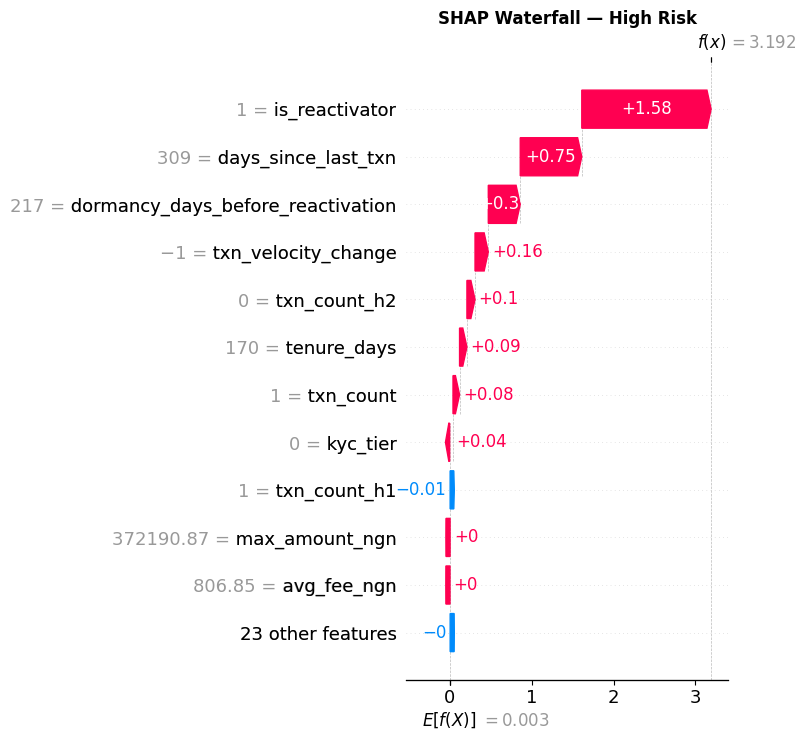

Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap\waterfall_high_risk.png


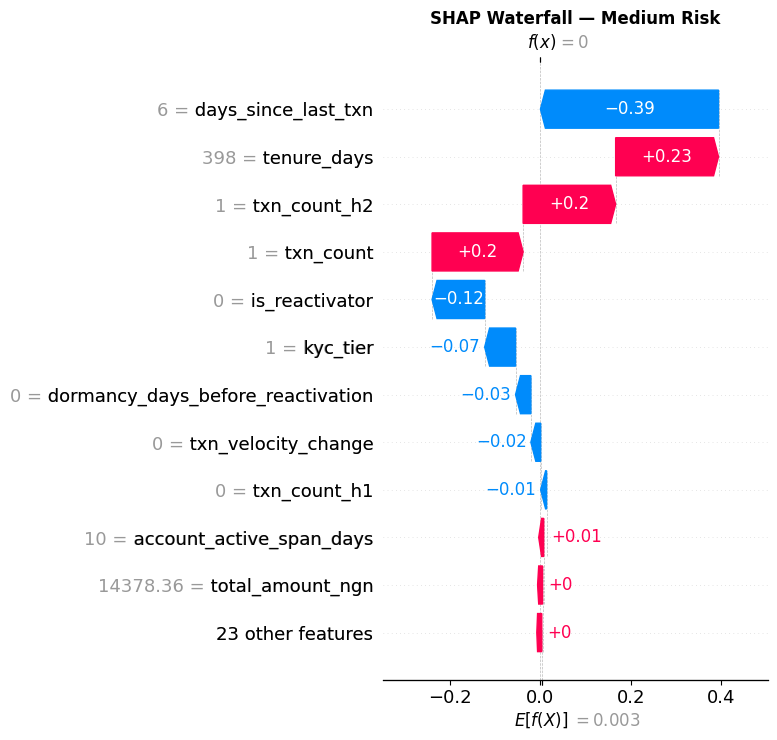

Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap\waterfall_medium_risk.png


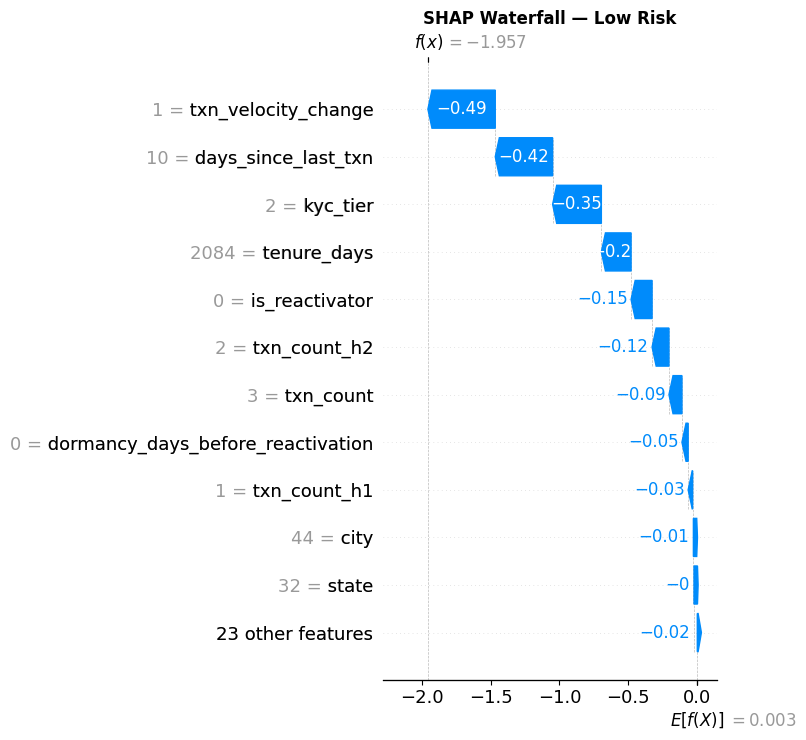

Saved: C:\Users\User\Desktop\315 - retain IQ\retainiq\outputs\figures\08_shap\waterfall_low_risk.png


In [12]:
# Waterfall plots for high / medium / low risk examples
for label, row_idx in examples.items():
    X_one = preprocessor.transform(df_test.iloc[[row_idx]][MODEL_COLS])
    if hasattr(X_one, "toarray"):
        X_one_dense = X_one.toarray()
    else:
        X_one_dense = np.asarray(X_one)

    one_shap = explainer.shap_values(X_one_dense)
    if isinstance(one_shap, list):
        one_shap = one_shap[1]

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if len(expected_value) > 1 else expected_value[0]

    explanation = shap.Explanation(
        values=one_shap[0],
        base_values=expected_value,
        data=X_one_dense[0],
        feature_names=feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"SHAP Waterfall — {label.replace('_', ' ').title()}", fontweight="bold")
    plt.tight_layout()
    out_path = SHAP_FIGURES / f"waterfall_{label}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")

In [13]:
# Save compact JSON summary for report/master notebook
top_features = shap_importance.head(10).to_dict(orient="records")

summary = {
    "sample_size": int(sample_size),
    "top_10_features": top_features,
    "figures": {
        "summary": str(SHAP_FIGURES / "shap_summary.png"),
        "bar": str(SHAP_FIGURES / "shap_bar.png"),
        "waterfall_high_risk": str(SHAP_FIGURES / "waterfall_high_risk.png"),
        "waterfall_medium_risk": str(SHAP_FIGURES / "waterfall_medium_risk.png"),
        "waterfall_low_risk": str(SHAP_FIGURES / "waterfall_low_risk.png"),
    }
}

with open(TABLES / "shap_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print(f"Saved: {TABLES / 'shap_summary.json'}")

{
  "sample_size": 2000,
  "top_10_features": [
    {
      "feature": "days_since_last_txn",
      "mean_abs_shap": 0.33345553278923035
    },
    {
      "feature": "txn_velocity_change",
      "mean_abs_shap": 0.1765504777431488
    },
    {
      "feature": "is_reactivator",
      "mean_abs_shap": 0.15594223141670227
    },
    {
      "feature": "tenure_days",
      "mean_abs_shap": 0.14829175174236298
    },
    {
      "feature": "txn_count_h2",
      "mean_abs_shap": 0.13228578865528107
    },
    {
      "feature": "kyc_tier",
      "mean_abs_shap": 0.13160330057144165
    },
    {
      "feature": "txn_count",
      "mean_abs_shap": 0.10238047689199448
    },
    {
      "feature": "dormancy_days_before_reactivation",
      "mean_abs_shap": 0.044508256018161774
    },
    {
      "feature": "txn_count_h1",
      "mean_abs_shap": 0.005908801686018705
    },
    {
      "feature": "txn_per_active_day",
      "mean_abs_shap": 0.0035924813710153103
    }
  ],
  "figures": {
    "